<a href="https://colab.research.google.com/github/DeisyUdec/week3/blob/main/semana_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# se importa las librerias
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#entradas de datos de compuertas logicas
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
# salida de cada compuerta lógica AND
y = np.array([[0],
              [0],
              [0],
              [1]])

In [28]:
#convierte los valores en 0 a 1
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
# se deriva la funcion del anterior
#metodo utilizando el backpropagation
def sigmoid_derivada(x):
    return x * (1 - x)
#si el valor de menor a o aparece 0 utilizando el ReLU
def relu(x):
    return np.maximum(0, x)
# se halla la derivada del relu
def relu_derivada(x):
    return np.where(x > 0, 1, 0)

In [29]:
#se crea el metodo de activación
#se define la cantidad de iteraciones
#tasa de aprendizaje
def entrenar(activacion='sigmoid', epochs=5000, lr=0.1):
    #fija numeros aleatorias para reproducibilidad
    np.random.seed(1)

    # Inicializar pesos y sesgos de la primera capa
    W1 = np.random.randn(2, 4)
    b1 = np.zeros((1, 4))
        # Inicializar pesos y sesgos de la primera capa
    W2 = np.random.randn(4, 1)
    b2 = np.zeros((1, 1))
    # se crea una lista para guardar el error
    losses = []
    #se crea el ciclo hasta que cumpla con la cantidad de interacciones
    for i in range(epochs):

        # multiplica la entrada por el peso + sesgo
        z1 = np.dot(X, W1) + b1
        # seaplica la funcion de activacion
        if activacion == 'sigmoid':
            a1 = sigmoid(z1)
        else:
            a1 = relu(z1)
        #se crea la segunda capa y se obtine la salida final
        z2 = np.dot(a1, W2) + b2
        output = sigmoid(z2)

        #determina la prediccion que tan lejos esta
        loss = np.mean((y - output)**2)
        #guarda el erros para graficar
        losses.append(loss)

        # calcula el error de salida
        d_output = (y - output) * sigmoid_derivada(output)
        # determina la cantidad  de gradientes a la segunda capa
        d_W2 = np.dot(a1.T, d_output)
        d_b2 = np.sum(d_output, axis=0, keepdims=True)
        #propaga el error hacia atras
        d_a1 = np.dot(d_output, W2.T)
        #aplica la derivada de la activación de la funcion
        if activacion == 'sigmoid':
            d_z1 = d_a1 * sigmoid_derivada(a1)
        else:
            d_z1 = d_a1 * relu_derivada(z1)
        #Determina gradientes d ela primera capa
        d_W1 = np.dot(X.T, d_z1)
        d_b1 = np.sum(d_z1, axis=0, keepdims=True)

        # Actualiza los pesos y los sesgos e inica el aprendizaje
        W1 += lr * d_W1
        b1 += lr * d_b1
        W2 += lr * d_W2
        b2 += lr * d_b2

        # Muestra el errror cada sierto tiempo
        if i % 1000 == 0:
            print(f"[{activacion}] Epoch {i} - Loss: {loss}")

    return losses, output


In [30]:
#entrena la funcion de sigmoid
loss_sigmoid, out_sigmoid = entrenar('sigmoid')

[sigmoid] Epoch 0 - Loss: 0.25580002642079924
[sigmoid] Epoch 1000 - Loss: 0.01904488798457356
[sigmoid] Epoch 2000 - Loss: 0.006418087961311542
[sigmoid] Epoch 3000 - Loss: 0.0034514777689138823
[sigmoid] Epoch 4000 - Loss: 0.00226265563628741


In [31]:
#Entrena la función de ReLu
loss_relu, out_relu = entrenar('relu')

[relu] Epoch 0 - Loss: 0.38479943486135976
[relu] Epoch 1000 - Loss: 0.0028621547600893174
[relu] Epoch 2000 - Loss: 0.001038387298114362
[relu] Epoch 3000 - Loss: 0.0006107351558113869
[relu] Epoch 4000 - Loss: 0.00043638502792027077


In [33]:
#Muestra las prediciones finales
print("\nResultados con Sigmoid:")
print(out_sigmoid)

print("\nResultados con ReLU:")
print(out_relu)


Resultados con Sigmoid:
[[4.22101086e-04]
 [4.48124219e-02]
 [3.48244195e-02]
 [9.41935944e-01]]

Resultados con ReLU:
[[0.0191922 ]
 [0.01919956]
 [0.01919913]
 [0.98342731]]


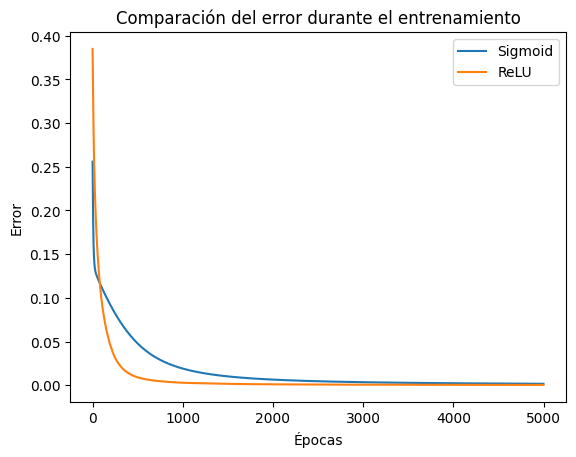

In [34]:
# grafica el error de cada modelo
plt.plot(loss_sigmoid, label='Sigmoid')
plt.plot(loss_relu, label='ReLU')
plt.title("Comparación del error durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error")
plt.legend()
plt.show()